## Récupération des données

In [3]:
import pandas as pd 
data = pd.read_csv('../Datasets/Dataset_Hypothyroïdie.xls')
data.head()

,Unnamed: 0,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72,M,f,f,f,f,f,f,f,...,y,0.6,y,15,y,1.48,y,10,n,?
1,hypothyroid,15,F,t,f,f,f,f,f,f,...,y,1.7,y,19,y,1.13,y,17,n,?
2,hypothyroid,24,M,f,f,f,f,f,f,f,...,y,0.2,y,4,y,1,y,0,n,?
3,hypothyroid,24,F,f,f,f,f,f,f,f,...,y,0.4,y,6,y,1.04,y,6,n,?
4,hypothyroid,77,M,f,f,f,f,f,f,f,...,y,1.2,y,57,y,1.28,y,44,n,?


## Nettoyage et Exploration des données 

In [4]:
data.shape

(3163, 26)

In [5]:
data.describe()

,Unnamed: 0,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
count,3163,3163,3163,3163,3163,3163,3163,3163,3163,3163,...,3163,3163,3163,3163,3163,3163,3163,3163,3163,3163
unique,2,93,3,2,2,2,2,2,2,2,...,2,70,2,269,2,159,2,281,2,53
top,negative,?,F,f,f,f,f,f,f,f,...,y,?,y,?,y,?,y,?,n,?
freq,3012,446,2182,2702,3108,3121,3059,2922,2920,3100,...,2468,695,2914,249,2915,248,2916,247,2903,2903


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3163 entries, 0 to 3162
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Unnamed: 0                 3163 non-null   object
 1   Age                        3163 non-null   object
 2   Sex                        3163 non-null   object
 3   on_thyroxine               3163 non-null   object
 4   query_on_thyroxine         3163 non-null   object
 5   on_antithyroid_medication  3163 non-null   object
 6   thyroid_surgery            3163 non-null   object
 7   query_hypothyroid          3163 non-null   object
 8   query_hyperthyroid         3163 non-null   object
 9   pregnant                   3163 non-null   object
 10  sick                       3163 non-null   object
 11  tumor                      3163 non-null   object
 12  lithium                    3163 non-null   object
 13  goitre                     3163 non-null   object
 14  TSH_meas

In [7]:
data.dtypes

Unnamed: 0                   object
Age                          object
Sex                          object
on_thyroxine                 object
query_on_thyroxine           object
on_antithyroid_medication    object
thyroid_surgery              object
query_hypothyroid            object
query_hyperthyroid           object
pregnant                     object
sick                         object
tumor                        object
lithium                      object
goitre                       object
TSH_measured                 object
TSH                          object
T3_measured                  object
T3                           object
TT4_measured                 object
TT4                          object
T4U_measured                 object
T4U                          object
FTI_measured                 object
FTI                          object
TBG_measured                 object
TBG                          object
dtype: object

In [8]:
data.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'thyroid_surgery', 'query_hypothyroid',
       'query_hyperthyroid', 'pregnant', 'sick', 'tumor', 'lithium', 'goitre',
       'TSH_measured', 'TSH', 'T3_measured', 'T3', 'TT4_measured', 'TT4',
       'T4U_measured', 'T4U', 'FTI_measured', 'FTI', 'TBG_measured', 'TBG'],
      dtype='object')

In [9]:
data.head()

,Unnamed: 0,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72,M,f,f,f,f,f,f,f,...,y,0.6,y,15,y,1.48,y,10,n,?
1,hypothyroid,15,F,t,f,f,f,f,f,f,...,y,1.7,y,19,y,1.13,y,17,n,?
2,hypothyroid,24,M,f,f,f,f,f,f,f,...,y,0.2,y,4,y,1,y,0,n,?
3,hypothyroid,24,F,f,f,f,f,f,f,f,...,y,0.4,y,6,y,1.04,y,6,n,?
4,hypothyroid,77,M,f,f,f,f,f,f,f,...,y,1.2,y,57,y,1.28,y,44,n,?


In [10]:
data.index

RangeIndex(start=0, stop=3163, step=1)

In [11]:
data = data.rename(columns= {'Unnamed: 0' : 'Hypothyroid(Y/N)'})

In [12]:
data['Hypothyroid(Y/N)'] = data['Hypothyroid(Y/N)'].replace({'hypothyroid': 't' , 'negative': 'f' })
data['Hypothyroid(Y/N)'].unique()

array(['t', 'f'], dtype=object)

In [13]:
val_cible = data['Hypothyroid(Y/N)'].value_counts()
val_cible

Hypothyroid(Y/N)
f    3012
t     151
Name: count, dtype: int64

In [14]:
columns = list(data.columns)
print('Les valeurs uniques :')
for col in columns : 
    print(f'{col} : {data[col].unique()}') 

Les valeurs uniques :
Hypothyroid(Y/N) : ['t' 'f']
Age : ['72' '15' '24' '77' '85' '64' '20' '42' '69' '75' '53' '59' '68' '50'
 '78' '65' '28' '43' '40' '84' '?' '83' '63' '73' '36' '27' '48' '71' '60'
 '34' '79' '62' '74' '32' '41' '70' '29' '5' '58' '35' '51' '22' '16' '44'
 '39' '47' '18' '17' '88' '56' '30' '45' '66' '52' '54' '80' '33' '38'
 '92' '67' '46' '13' '89' '61' '49' '26' '57' '31' '90' '81' '25' '37'
 '76' '87' '23' '55' '86' '98' '21' '97' '1' '6' '14' '82' '11' '19' '9'
 '12' '10' '8' '7' '4' '93']
Sex : ['M' 'F' '?']
on_thyroxine : ['f' 't']
query_on_thyroxine : ['f' 't']
on_antithyroid_medication : ['f' 't']
thyroid_surgery : ['f' 't']
query_hypothyroid : ['f' 't']
query_hyperthyroid : ['f' 't']
pregnant : ['f' 't']
sick : ['f' 't']
tumor : ['f' 't']
lithium : ['f' 't']
goitre : ['f' 't']
TSH_measured : ['y' 'n']
TSH : ['30' '145' '0' '430' '7.3' '138' '7.7' '21' '92' '48' '36' '15' '15.3'
 '25' '61' '28' '170' '54' '216' '56' '71' '46' '70' '34' '53' '9.4' '126'
 '

In [15]:
cols_obj = data.select_dtypes(include=object).columns
for col_obj in cols_obj :
    print(f'{col_obj} : {data[col_obj].unique()}')

Hypothyroid(Y/N) : ['t' 'f']
Age : ['72' '15' '24' '77' '85' '64' '20' '42' '69' '75' '53' '59' '68' '50'
 '78' '65' '28' '43' '40' '84' '?' '83' '63' '73' '36' '27' '48' '71' '60'
 '34' '79' '62' '74' '32' '41' '70' '29' '5' '58' '35' '51' '22' '16' '44'
 '39' '47' '18' '17' '88' '56' '30' '45' '66' '52' '54' '80' '33' '38'
 '92' '67' '46' '13' '89' '61' '49' '26' '57' '31' '90' '81' '25' '37'
 '76' '87' '23' '55' '86' '98' '21' '97' '1' '6' '14' '82' '11' '19' '9'
 '12' '10' '8' '7' '4' '93']
Sex : ['M' 'F' '?']
on_thyroxine : ['f' 't']
query_on_thyroxine : ['f' 't']
on_antithyroid_medication : ['f' 't']
thyroid_surgery : ['f' 't']
query_hypothyroid : ['f' 't']
query_hyperthyroid : ['f' 't']
pregnant : ['f' 't']
sick : ['f' 't']
tumor : ['f' 't']
lithium : ['f' 't']
goitre : ['f' 't']
TSH_measured : ['y' 'n']
TSH : ['30' '145' '0' '430' '7.3' '138' '7.7' '21' '92' '48' '36' '15' '15.3'
 '25' '61' '28' '170' '54' '216' '56' '71' '46' '70' '34' '53' '9.4' '126'
 '10' '530' '35' '65' '5

In [16]:
cols = ['TSH_measured','T3_measured','TT4_measured','T4U_measured','FTI_measured','TBG_measured']
for col in cols : 
    data[col] = data[col].replace({'y':'t' , 'n':'f'})
    print(f'{col} : {data[col].unique()}')

TSH_measured : ['t' 'f']
T3_measured : ['t' 'f']
TT4_measured : ['t' 'f']
T4U_measured : ['t' 'f']
FTI_measured : ['t' 'f']
TBG_measured : ['f' 't']


In [17]:
cols_obj = data.select_dtypes(include=object).columns
for col_obj in cols_obj :
    print(f'{col_obj} : {data[col_obj].unique()}')

Hypothyroid(Y/N) : ['t' 'f']
Age : ['72' '15' '24' '77' '85' '64' '20' '42' '69' '75' '53' '59' '68' '50'
 '78' '65' '28' '43' '40' '84' '?' '83' '63' '73' '36' '27' '48' '71' '60'
 '34' '79' '62' '74' '32' '41' '70' '29' '5' '58' '35' '51' '22' '16' '44'
 '39' '47' '18' '17' '88' '56' '30' '45' '66' '52' '54' '80' '33' '38'
 '92' '67' '46' '13' '89' '61' '49' '26' '57' '31' '90' '81' '25' '37'
 '76' '87' '23' '55' '86' '98' '21' '97' '1' '6' '14' '82' '11' '19' '9'
 '12' '10' '8' '7' '4' '93']
Sex : ['M' 'F' '?']
on_thyroxine : ['f' 't']
query_on_thyroxine : ['f' 't']
on_antithyroid_medication : ['f' 't']
thyroid_surgery : ['f' 't']
query_hypothyroid : ['f' 't']
query_hyperthyroid : ['f' 't']
pregnant : ['f' 't']
sick : ['f' 't']
tumor : ['f' 't']
lithium : ['f' 't']
goitre : ['f' 't']
TSH_measured : ['t' 'f']
TSH : ['30' '145' '0' '430' '7.3' '138' '7.7' '21' '92' '48' '36' '15' '15.3'
 '25' '61' '28' '170' '54' '216' '56' '71' '46' '70' '34' '53' '9.4' '126'
 '10' '530' '35' '65' '5

In [18]:
import numpy as np 
# Remplacer "?" par NaN 
# data = data.replace({'?' : np.nan})
data.replace('?' , np.nan , inplace=True)

In [19]:
data.isnull().sum()

Hypothyroid(Y/N)                0
Age                           446
Sex                            73
on_thyroxine                    0
query_on_thyroxine              0
on_antithyroid_medication       0
thyroid_surgery                 0
query_hypothyroid               0
query_hyperthyroid              0
pregnant                        0
sick                            0
tumor                           0
lithium                         0
goitre                          0
TSH_measured                    0
TSH                           468
T3_measured                     0
T3                            695
TT4_measured                    0
TT4                           249
T4U_measured                    0
T4U                           248
FTI_measured                    0
FTI                           247
TBG_measured                    0
TBG                          2903
dtype: int64

In [20]:
data['TBG'].isnull().sum()

np.int64(2903)

In [21]:
# Il y'a un grand nombre des valeurs manquantes dans la colonne 'TBG' donc on la supprime
data.drop(columns=['TBG'] , inplace=True)

In [22]:
data.head()

,Hypothyroid(Y/N),Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured
0,t,72,M,f,f,f,f,f,f,f,...,30,t,0.6,t,15,t,1.48,t,10,f
1,t,15,F,t,f,f,f,f,f,f,...,145,t,1.7,t,19,t,1.13,t,17,f
2,t,24,M,f,f,f,f,f,f,f,...,0,t,0.2,t,4,t,1,t,0,f
3,t,24,F,f,f,f,f,f,f,f,...,430,t,0.4,t,6,t,1.04,t,6,f
4,t,77,M,f,f,f,f,f,f,f,...,7.3,t,1.2,t,57,t,1.28,t,44,f


In [23]:
# Convertir les valeurs numériques (int , float) sous format text (string) en numériques (int , float)
cols = ['Age' ,'TSH' , 'T3' , 'TT4','T4U' , 'FTI']
for col in cols : 
    data[col] = pd.to_numeric(data[col] , errors='coerce')  # Convertit en float, met NaN si erreur

In [24]:
data.dtypes

Hypothyroid(Y/N)              object
Age                          float64
Sex                           object
on_thyroxine                  object
query_on_thyroxine            object
on_antithyroid_medication     object
thyroid_surgery               object
query_hypothyroid             object
query_hyperthyroid            object
pregnant                      object
sick                          object
tumor                         object
lithium                       object
goitre                        object
TSH_measured                  object
TSH                          float64
T3_measured                   object
T3                           float64
TT4_measured                  object
TT4                          float64
T4U_measured                  object
T4U                          float64
FTI_measured                  object
FTI                          float64
TBG_measured                  object
dtype: object

In [25]:
data.shape

(3163, 25)

In [26]:
# Séparer les colonnes numériques et catégoriques
cat_cols = data.select_dtypes(include=object).columns
num_cols = data.select_dtypes(include=['float64', 'int64']).columns

In [27]:
from sklearn.preprocessing import LabelEncoder

# Encoder les colonnes catégoriques avec LabelEncoder
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))  # Convertir NaN en string "nan"
    label_encoders[col] = le


In [28]:
data

,Hypothyroid(Y/N),Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured
0,1,72.0,1,0,0,0,0,0,0,0,...,30.0,1,0.6,1,15.0,1,1.48,1,10.0,0
1,1,15.0,0,1,0,0,0,0,0,0,...,145.0,1,1.7,1,19.0,1,1.13,1,17.0,0
2,1,24.0,1,0,0,0,0,0,0,0,...,0.0,1,0.2,1,4.0,1,1.00,1,0.0,0
3,1,24.0,0,0,0,0,0,0,0,0,...,430.0,1,0.4,1,6.0,1,1.04,1,6.0,0
4,1,77.0,1,0,0,0,0,0,0,0,...,7.3,1,1.2,1,57.0,1,1.28,1,44.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3158,0,58.0,0,0,0,0,0,0,0,0,...,5.8,1,1.7,1,86.0,1,0.91,1,95.0,0
3159,0,29.0,0,0,0,0,0,0,0,0,...,0.8,1,1.8,1,99.0,1,1.01,1,98.0,0
3160,0,77.0,1,0,0,0,0,0,0,0,...,1.2,1,0.6,1,71.0,1,0.68,1,104.0,0
3161,0,74.0,0,0,0,0,0,0,0,0,...,1.3,1,0.1,1,65.0,1,0.48,1,137.0,0


In [29]:
from sklearn.impute import KNNImputer

# Appliquer KNNImputer sur toutes les colonnes
imputer = KNNImputer(n_neighbors=3)
data = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)


# Correction : S'assurer que les valeurs imputées restent valides
for col in cat_cols:
#    print(col)
   data[col] = data[col].astype(int) #  Forcer en entier
   # data[col] = label_encoders[col].inverse_transform(data[col])  #  Convertir en catégories

# Afficher la dataset après imputation
print("\nDataset après imputation :\n", data.head())



Dataset après imputation :
    Hypothyroid(Y/N)   Age  Sex  on_thyroxine  query_on_thyroxine  \
0                 1  72.0    1             0                   0   
1                 1  15.0    0             1                   0   
2                 1  24.0    1             0                   0   
3                 1  24.0    0             0                   0   
4                 1  77.0    1             0                   0   

   on_antithyroid_medication  thyroid_surgery  query_hypothyroid  \
0                          0                0                  0   
1                          0                0                  0   
2                          0                0                  0   
3                          0                0                  0   
4                          0                0                  0   

   query_hyperthyroid  pregnant  ...    TSH  T3_measured   T3  TT4_measured  \
0                   0         0  ...   30.0            1  0.6             

In [30]:
# Convertir 'Age' ,'TT4', 'FTI' en int et 'TSH' , 'T3' , 'T4U' sont déjà convertit en float
data['Age'] = data['Age'].astype(int)
data['TT4'] = data['TT4'].astype(int)
data['FTI'] = data['FTI'].astype(int)
print(data['Age'].dtype)
print(data['TT4'].dtype)
print(data['FTI'].dtype)

int64
int64
int64


In [31]:
data

,Hypothyroid(Y/N),Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured
0,1,72,1,0,0,0,0,0,0,0,...,30.0,1,0.6,1,15,1,1.48,1,10,0
1,1,15,0,1,0,0,0,0,0,0,...,145.0,1,1.7,1,19,1,1.13,1,17,0
2,1,24,1,0,0,0,0,0,0,0,...,0.0,1,0.2,1,4,1,1.00,1,0,0
3,1,24,0,0,0,0,0,0,0,0,...,430.0,1,0.4,1,6,1,1.04,1,6,0
4,1,77,1,0,0,0,0,0,0,0,...,7.3,1,1.2,1,57,1,1.28,1,44,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3158,0,58,0,0,0,0,0,0,0,0,...,5.8,1,1.7,1,86,1,0.91,1,95,0
3159,0,29,0,0,0,0,0,0,0,0,...,0.8,1,1.8,1,99,1,1.01,1,98,0
3160,0,77,1,0,0,0,0,0,0,0,...,1.2,1,0.6,1,71,1,0.68,1,104,0
3161,0,74,0,0,0,0,0,0,0,0,...,1.3,1,0.1,1,65,1,0.48,1,137,0


In [32]:
data.isnull().sum()

Hypothyroid(Y/N)             0
Age                          0
Sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
thyroid_surgery              0
query_hypothyroid            0
query_hyperthyroid           0
pregnant                     0
sick                         0
tumor                        0
lithium                      0
goitre                       0
TSH_measured                 0
TSH                          0
T3_measured                  0
T3                           0
TT4_measured                 0
TT4                          0
T4U_measured                 0
T4U                          0
FTI_measured                 0
FTI                          0
TBG_measured                 0
dtype: int64

In [33]:
val_cible = data['Hypothyroid(Y/N)'].value_counts()
val_cible

Hypothyroid(Y/N)
0    3012
1     151
Name: count, dtype: int64

In [34]:
data.shape

(3163, 25)

In [35]:
# Sélectionner les indices des 1512 premières lignes où 'Hypothyroid(Y/N)' == 'f'
# indices_to_remove = data[data['Hypothyroid(Y/N)'] == 0 ].index[:1512]
indices_to_remove = data[data['Hypothyroid(Y/N)'] == 0 ].index[:2000]
# Supprimer ces lignes
data = data.drop(indices_to_remove)
data

,Hypothyroid(Y/N),Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured
0,1,72,1,0,0,0,0,0,0,0,...,30.0,1,0.6,1,15,1,1.48,1,10,0
1,1,15,0,1,0,0,0,0,0,0,...,145.0,1,1.7,1,19,1,1.13,1,17,0
2,1,24,1,0,0,0,0,0,0,0,...,0.0,1,0.2,1,4,1,1.00,1,0,0
3,1,24,0,0,0,0,0,0,0,0,...,430.0,1,0.4,1,6,1,1.04,1,6,0
4,1,77,1,0,0,0,0,0,0,0,...,7.3,1,1.2,1,57,1,1.28,1,44,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3158,0,58,0,0,0,0,0,0,0,0,...,5.8,1,1.7,1,86,1,0.91,1,95,0
3159,0,29,0,0,0,0,0,0,0,0,...,0.8,1,1.8,1,99,1,1.01,1,98,0
3160,0,77,1,0,0,0,0,0,0,0,...,1.2,1,0.6,1,71,1,0.68,1,104,0
3161,0,74,0,0,0,0,0,0,0,0,...,1.3,1,0.1,1,65,1,0.48,1,137,0


In [36]:
val_cible = data['Hypothyroid(Y/N)'].value_counts()
val_cible

Hypothyroid(Y/N)
0    1012
1     151
Name: count, dtype: int64

In [37]:
data.dtypes

Hypothyroid(Y/N)               int64
Age                            int64
Sex                            int64
on_thyroxine                   int64
query_on_thyroxine             int64
on_antithyroid_medication      int64
thyroid_surgery                int64
query_hypothyroid              int64
query_hyperthyroid             int64
pregnant                       int64
sick                           int64
tumor                          int64
lithium                        int64
goitre                         int64
TSH_measured                   int64
TSH                          float64
T3_measured                    int64
T3                           float64
TT4_measured                   int64
TT4                            int64
T4U_measured                   int64
T4U                          float64
FTI_measured                   int64
FTI                            int64
TBG_measured                   int64
dtype: object

## Modélisation 

### 1) Division de données en : Données d'entrées (Input) et Données de Sorties (Output)

In [38]:
x = data.drop('Hypothyroid(Y/N)' , axis=1)
x_list = list(x.columns)
x = np.array(x)
y = data['Hypothyroid(Y/N)']
y=np.array(y)

print(x_list)
print(x)
print(y)

['Age', 'Sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'thyroid_surgery', 'query_hypothyroid', 'query_hyperthyroid', 'pregnant', 'sick', 'tumor', 'lithium', 'goitre', 'TSH_measured', 'TSH', 'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U', 'FTI_measured', 'FTI', 'TBG_measured']
[[ 72.   1.   0. ...   1.  10.   0.]
 [ 15.   0.   1. ...   1.  17.   0.]
 [ 24.   1.   0. ...   1.   0.   0.]
 ...
 [ 77.   1.   0. ...   1. 104.   0.]
 [ 74.   0.   0. ...   1. 137.   0.]
 [ 56.   0.   1. ...   1. 143.   0.]]
[1 1 1 ... 0 0 0]


### 2) Division de données en : Données d'Apprentissage (Data Training : 90%) et Données de Test (Data Testing : 10%)

In [39]:
data.shape

(1163, 25)

In [40]:
from sklearn.model_selection import train_test_split 

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.1 , random_state=40)

print('Training Data x : ' , x_train.shape)
print('Training Data y : ' ,y_train.shape)
print('Testing Data x : ' , x_test.shape)
print('Testing Data y : ' ,y_test.shape)

Training Data x :  (1046, 24)
Training Data y :  (1046,)
Testing Data x :  (117, 24)
Testing Data y :  (117,)


In [41]:
# Optimisation
from collections import Counter
from imblearn.over_sampling import SMOTE

# 2. Afficher la répartition des classes avant SMOTE
print("Répartition des classes avant SMOTE:", Counter(y_train))

# 3. Initialiser SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)

# 4. Appliquer SMOTE pour resampler x_train et y_train
x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

# 5. Afficher la répartition des classes après SMOTE
print("Répartition des classes après SMOTE:", Counter(y_resampled))



Répartition des classes avant SMOTE: Counter({np.int64(0): 913, np.int64(1): 133})
Répartition des classes après SMOTE: Counter({np.int64(0): 913, np.int64(1): 913})


In [42]:
from sklearn.utils import shuffle

x_test, y_test = shuffle(x_test, y_test, random_state=42)

x_final_test= x_test[:5]
y_final_test = y_test[:5]

x_test= x_test[5:]
y_test = y_test[5:]

print("Testing Data:", x_test.shape, y_test.shape)
print("Final Testing Data:", x_final_test.shape, y_final_test.shape)
print(y_final_test) 

Testing Data: (112, 24) (112,)
Final Testing Data: (5, 24) (5,)
[0 0 0 0 0]


### 3) Comparaison des algorithmes de Machine Learning : 
* Gradient Boosting 
* XGBoost
* Random Forest

on Choisit des Algorithmes de classification comme (Gradient Boosting classifier - XGBoost classifier - Random Forest classifier)7 car : 
on a un probléme de classification puisque la variable cible (Target) est catégorielle  

In [43]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score , roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#### a) Gradient Boosting

##### * Créer et Entraîner le modéle

In [44]:
# Créer le modèle Gradient Boosting

model_gradientBoosting = GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

# Entraîner le modèle
model_gradientBoosting.fit(x_train, y_train)

# Prédiction
y_pred = model_gradientBoosting.predict(x_test)

##### * Évaluer la performance du modèle par le calcul des métriques d'évaluation

##### -- Matrice de confusion

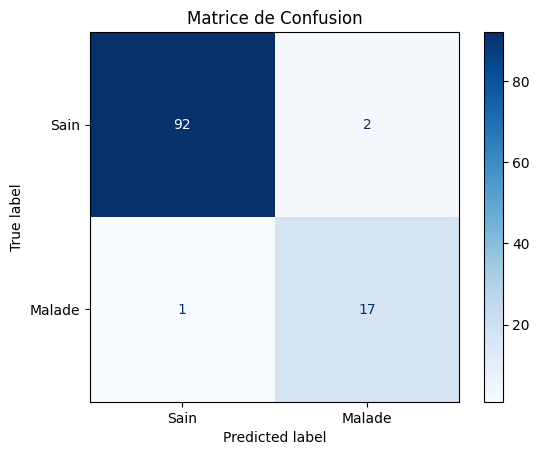

In [45]:
# Calculer la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sain", "Malade"])
# Afficher la matrice de confusion avec un graphique
disp.plot(cmap="Blues")
plt.title('Matrice de Confusion')
# Afficher le graphique
plt.show()

##### -- Métriques :
* Accuracy
* Recall
* Precision
* F1-Score
* AUC-ROC

In [46]:
# Calculer les métriques
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred) 
auc_roc = roc_auc_score(y_test, y_pred)

# Afficher les résultats
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'Precision: {precision}')
print(f'F1-Score: {f1}')
print(f'AUC-ROC: {auc_roc}') 


Accuracy: 0.9732142857142857
Recall: 0.9444444444444444
Precision: 0.8947368421052632
F1-Score: 0.918918918918919
AUC-ROC: 0.9615839243498818


##### -- Courbe ROC-AUC 

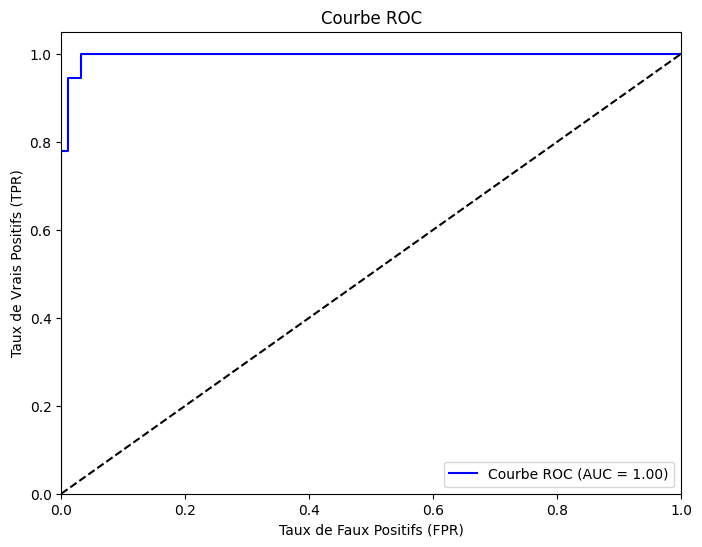

In [47]:
y_pred_prob = model_gradientBoosting.predict_proba(x_test)[:, 1]  # Probabilité de la classe positive
# Calculer les courbes ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # y_pred_prob = probabilité de la classe positive
roc_auc = auc(fpr, tpr)  # Calculer l'AUC

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonale aléatoire (ligne de hasard)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

#### b) XGBoost

##### * Créer et Entraîner le modéle

In [48]:
# Créer le modèle XGBoost

model_xgboost = xgb.XGBClassifier(
   n_estimators =100 ,
   learning_rate=0.1 , 
   max_depth=3 , 
   random_state=42
)


# Entraîner le modèle
model_xgboost.fit(x_train, y_train)

# Prédiction
y_pred = model_xgboost.predict(x_test)


##### * Évaluer la performance du modèle par le calcul des métriques d'évaluation

##### -- Matrice de confusion

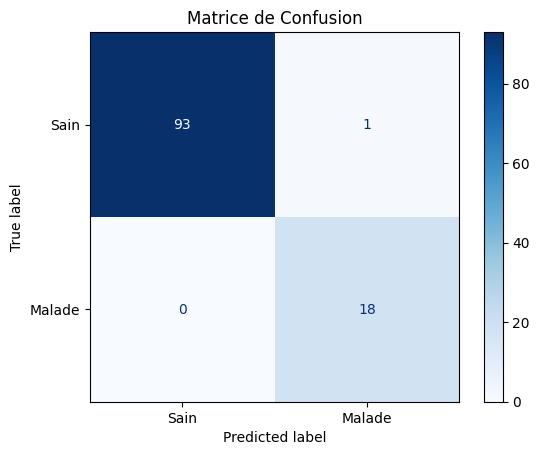

In [49]:
# Calculer la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sain", "Malade"])
# Afficher la matrice de confusion avec un graphique
disp.plot(cmap="Blues")
plt.title('Matrice de Confusion')
# Afficher le graphique
plt.show()

##### -- Métriques :
* Accuracy
* Recall
* Precision
* F1-Score
* AUC-ROC

In [50]:
# Calculer les métriques
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred) 
auc_roc = roc_auc_score(y_test, y_pred)

# Afficher les résultats
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'Precision: {precision}')
print(f'F1-Score: {f1}')
print(f'AUC-ROC: {auc_roc}') 


Accuracy: 0.9910714285714286
Recall: 1.0
Precision: 0.9473684210526315
F1-Score: 0.972972972972973
AUC-ROC: 0.9946808510638299


##### -- Courbe ROC-AUC

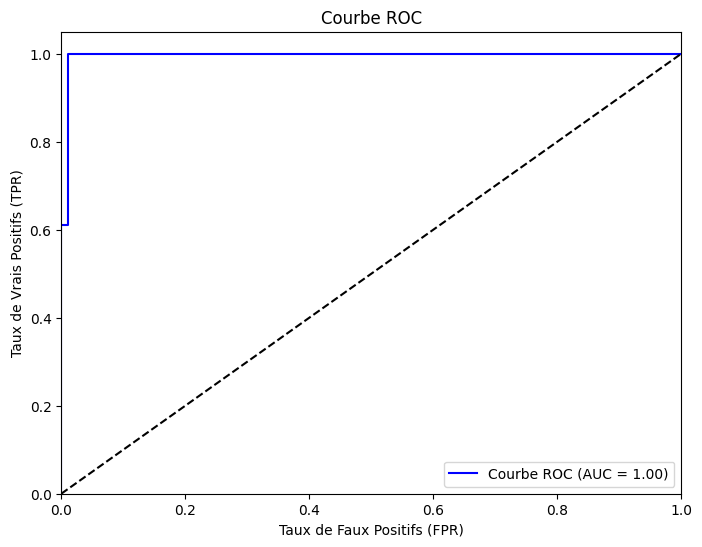

In [ ]:
y_pred_prob = model_xgboost.predict_proba(x_test)[:, 1]  # Probabilité de la classe positive
# Calculer les courbes ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # y_pred_prob = probabilité de la classe positive
roc_auc = auc(fpr, tpr)  # Calculer l'AUC

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonale aléatoire (ligne de hasard)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

                      Feature  Importance
22                        FTI    0.808165
14                        TSH    0.059366
5             thyroid_surgery    0.027865
18                        TT4    0.020245
0                         Age    0.019930
16                         T3    0.018086
2                on_thyroxine    0.016984
6           query_hypothyroid    0.015892
20                        T4U    0.013467
4   on_antithyroid_medication    0.000000
1                         Sex    0.000000
3          query_on_thyroxine    0.000000
7          query_hyperthyroid    0.000000
8                    pregnant    0.000000
10                      tumor    0.000000
9                        sick    0.000000
15                T3_measured    0.000000
13               TSH_measured    0.000000
12                     goitre    0.000000
11                    lithium    0.000000
19               T4U_measured    0.000000
17               TT4_measured    0.000000
21               FTI_measured    0

C:\Users\DELL\AppData\Local\Temp\ipykernel_13044\1201411222.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='Blues_r')


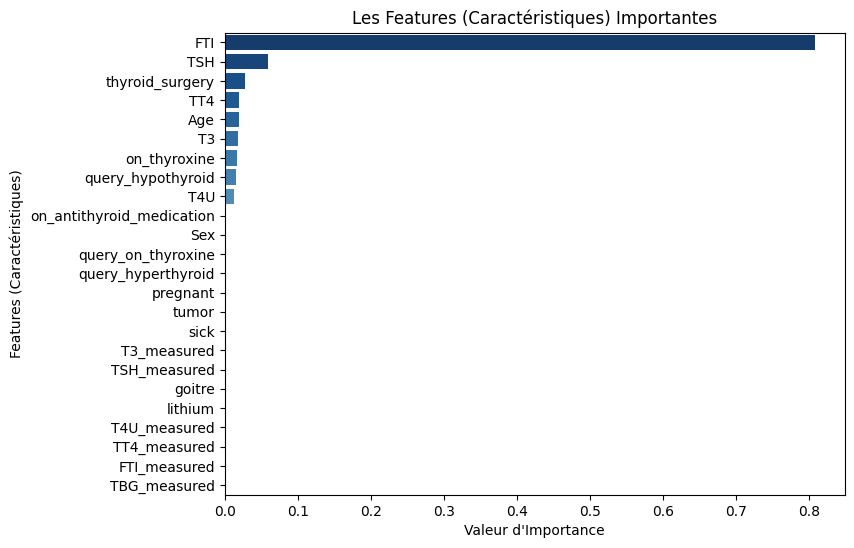

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb  # Assurez-vous que XGBoost est installé

def val_importance(model, feature_names):
    """Affiche l'importance des features du modèle XGBoost."""
    
    # Obtenir les valeurs d'importance des features
    importance_val = model.feature_importances_
    
    # Associer chaque feature à sa valeur d'importance
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_val})
    
    # Trier par ordre décroissant
    feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)
    
    # Afficher les features et leur importance
    print(feature_importance_df)
    
    # Tracer le diagramme des valeurs importantes des features
    plt.figure(figsize=(8, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='Blues_r')
    
    plt.title("Les Features (Caractéristiques) Importantes")
    plt.xlabel("Valeur d'Importance")
    plt.ylabel("Features (Caractéristiques)")
    plt.show()

# Exemple d'utilisation :
# Supposons que `xgb_model` est ton modèle entraîné et `x_list` contient les noms des features.
val_importance(model_xgboost, x_list)


#### c) Random Forest

##### * Créer et Entraîner le modéle

In [ ]:
# Créer le modèle Random Forest

model_randomForest = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    random_state=42
    )


# Entraîner le modèle
model_randomForest.fit(x_train, y_train)

# Prédiction
y_pred = model_randomForest.predict(x_test)

##### * Évaluer la performance du modèle par le calcul des métriques d'évaluation

##### -- Matrice de confusion

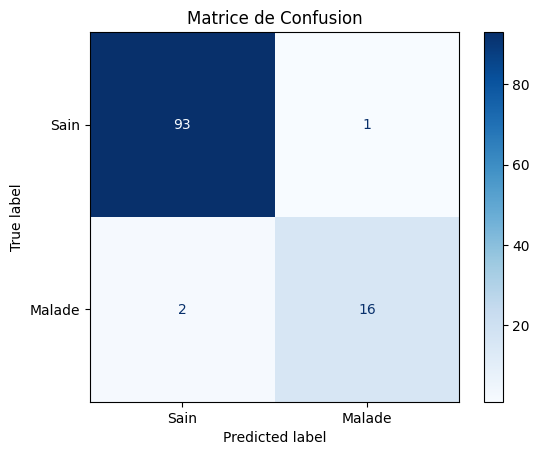

In [ ]:
# Calculer la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sain", "Malade"])
# Afficher la matrice de confusion avec un graphique
disp.plot(cmap="Blues")
plt.title('Matrice de Confusion')
# Afficher le graphique
plt.show()

##### -- Métriques :
* Accuracy
* Recall
* Precision
* F1-Score
* AUC-ROC

In [ ]:
# Calculer les métriques
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred) 
auc_roc = roc_auc_score(y_test, y_pred)

# Afficher les résultats
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'Precision: {precision}')
print(f'F1-Score: {f1}')
print(f'AUC-ROC: {auc_roc}') 


Accuracy: 0.9732142857142857
Recall: 0.8888888888888888
Precision: 0.9411764705882353
F1-Score: 0.9142857142857143
AUC-ROC: 0.9391252955082743


##### -- Courbe ROC-AUC

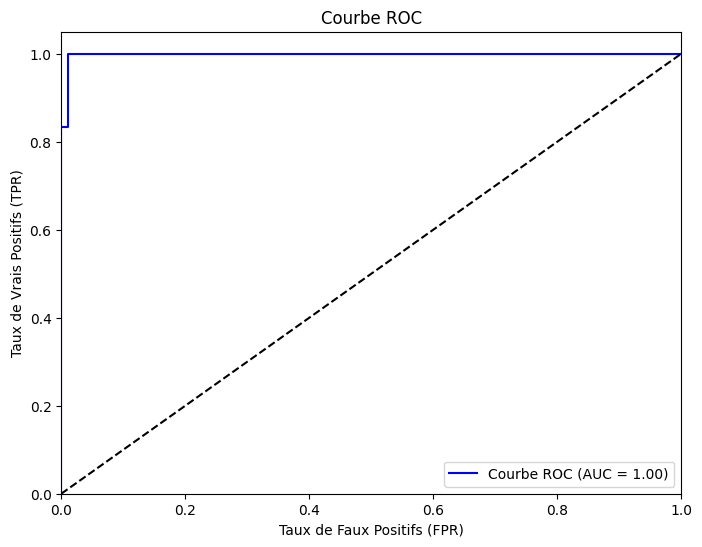

In [ ]:
y_pred_prob = model_randomForest.predict_proba(x_test)[:, 1]  # Probabilité de la classe positive
# Calculer les courbes ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # y_pred_prob = probabilité de la classe positive
roc_auc = auc(fpr, tpr)  # Calculer l'AUC

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonale aléatoire (ligne de hasard)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

### 4) Optimisation des Hyperparamètres avec GridSearchCV pour améliorer la Performance du Modèle

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Définir les modèles
models = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Définir les grilles de paramètres pour chaque modèle
param_grids = {
    "Gradient Boosting": {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.7, 1.0],
        'min_samples_split': [2, 5]
    },
    "XGBoost": {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.7, 0.9],
        'colsample_bytree': [0.7, 1.0],
        'gamma': [0, 0.1]
    },
    "Random Forest": {
        'n_estimators': [50, 100],
        'max_depth': [None, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }
}

# Fonction pour exécuter GridSearchCV, faire la prédiction et afficher les métriques
def run_grid_search(models, param_grids, x_train, y_train, x_test, y_test):
    results = {}
    for model_name, model in models.items():
        print(f"\nOptimisation de {model_name} : ")
        
        # GridSearchCV avec les paramètres spécifiés
        grid_search = GridSearchCV(model, param_grids[model_name], cv=3, n_jobs=-1, verbose=2)
        grid_search.fit(x_train, y_train)
        
        # Stocker les résultats
        best_model = grid_search.best_estimator_
        results[model_name] = {
            'Best Params': grid_search.best_params_,
            'Best Score': grid_search.best_score_,
            'Best Model': best_model
        }
        
        # Afficher les meilleurs hyperparamètres pour chaque modèle
        print(f"Meilleurs paramètres pour {model_name}:")
        for param, value in grid_search.best_params_.items():
            print(f"{param} = {value}")
        
        print(f"Meilleure précision (cross-validation) pour {model_name}: {grid_search.best_score_:.4f}")
        
        # Faire la prédiction avec le meilleur modèle
        y_pred = best_model.predict(x_test)
        y_pred_proba = best_model.predict_proba(x_test)[:, 1]  # Probabilités pour AUC-ROC
        
        # Calcul des métriques sur le test set
        test_accuracy = accuracy_score(y_test, y_pred)
        test_recall = recall_score(y_test, y_pred, average='macro')
        test_precision = precision_score(y_test, y_pred, average='macro')
        test_f1 = f1_score(y_test, y_pred, average='macro')
        test_auc_roc = roc_auc_score(y_test, y_pred_proba)

        print(f"\nÉvaluation sur le test set de {model_name} :")
        print(f"  Accuracy  : {test_accuracy}")
        print(f"  Recall    : {test_recall}")
        print(f"  Précision : {test_precision}")
        print(f"  F1-Score  : {test_f1}")
        print(f"  AUC-ROC   : {test_auc_roc}\n")
    
    return results

results = run_grid_search(models, param_grids, x_train, y_train, x_test, y_test)



Optimisation de Gradient Boosting : 
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Meilleurs paramètres pour Gradient Boosting:
learning_rate = 0.01
max_depth = 3
min_samples_split = 2
n_estimators = 100
subsample = 0.7
Meilleure précision (cross-validation) pour Gradient Boosting: 0.9809

Évaluation sur le test set de Gradient Boosting :
  Accuracy  : 0.9821428571428571
  Recall    : 0.966903073286052
  Précision : 0.966903073286052
  F1-Score  : 0.966903073286052
  AUC-ROC   : 0.9976359338061466


Optimisation de XGBoost : 
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Meilleurs paramètres pour XGBoost:
colsample_bytree = 1.0
gamma = 0
learning_rate = 0.01
max_depth = 3
n_estimators = 100
subsample = 0.9
Meilleure précision (cross-validation) pour XGBoost: 0.9799

Évaluation sur le test set de XGBoost :
  Accuracy  : 0.9910714285714286
  Recall    : 0.9946808510638299
  Précision : 0.9736842105263157
  F1-Score  : 0.9838126896950427
  AUC-ROC   : 0.996

### 4) Comparaison avec l'algorithme de Deep Learning : 
* Réseau de Neurones artificiels (ANN : Artificial Neural Network)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# 1 Prétraitement des données (standardisation)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 2 Construction du modèle ANN
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),  # Couche d'entrée     (32 →  64 →  128)
    Dropout(0.3),  # Pour éviter l'overfitting   entre 0.2 et 0.5 # Trop de dropout (ex: 0.5) peut réduire l’apprentissage  -  Trop peu (ex: 0.1) peut ne pas suffire à régulariser
    Dense(32, activation='relu'),  # Couche cachée Réduire progressivement les neurones (128 → 64 → 32) permet une bonne extraction des features
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Couche de sortie (classification binaire)
])

# 3 Compilation du modèle
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early Stopping pour éviter l'overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# Trop peu d’epochs (ex: 10-20) → le modèle n’a pas le temps d’apprendre suffisamment - Trop d’epochs (ex: 100-200) → risque d’overfitting (le modèle apprend trop sur les données d’entraînement mais généralise mal).
# 4 Entraînement du modèle
model.fit(x_train_scaled, y_train, epochs=80, batch_size=64, validation_data=(x_test_scaled, y_test), verbose=1)
# Petit batch (ex: 8-16) → plus précis mais plus lent  - Grand batch (ex: 64-256) → plus rapide mais moins bon en généralisation - Tester 16 ou 64

# 5 Évaluation du modèle
y_pred_proba = model.predict(x_test_scaled)  # Probabilités
y_pred = (y_pred_proba > 0.5).astype(int)  # Seuil à 0.5 pour la classification

# 6 Calcul des métriques
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

# 7 Affichage des résultats
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'Precision: {precision}')
print(f'F1-Score: {f1}')
print(f'AUC-ROC: {auc_roc}')


Epoch 1/80


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4902 - loss: 0.6956 - val_accuracy: 0.8393 - val_loss: 0.5457
Epoch 2/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8762 - loss: 0.4554 - val_accuracy: 0.8393 - val_loss: 0.3743
Epoch 3/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8780 - loss: 0.2769 - val_accuracy: 0.8571 - val_loss: 0.2912
Epoch 4/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8936 - loss: 0.2084 - val_accuracy: 0.9286 - val_loss: 0.2086
Epoch 5/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9542 - loss: 0.1440 - val_accuracy: 0.9464 - val_loss: 0.1565
Epoch 6/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9713 - loss: 0.1060 - val_accuracy: 0.9554 - val_loss: 0.1508
Epoch 7/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9695 - loss: 0.0856 - val_accuracy: 0.9554 - val_loss: 0.1498
Epoch 8/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9762 - loss: 0.0654 - val_accuracy: 0.9554 - val_loss: 0.1726
Ep

### 5) Test réel du modèle choisi : XGBoost

In [ ]:
y_final_pred = model_xgboost.predict(x_final_test)
print(f'Rélle : {y_final_test}')
print( f'Prédiction : {y_final_pred}')

Rélle : [1 0 0 1 1]
Prédiction : [1 0 0 1 1]


### 6) Sauvegarde du modèle choisi : XGBoost

In [ ]:
import pickle

In [ ]:
with open ('hypothyroïdie_model_xgboost.pkl', 'wb' ) as file :
     pickle.dump(model_xgboost , file)

In [ ]:
# with open ('hypothyroïdie_model_xgboost.pkl', 'rb' ) as file : 
#     hypothyroïdie_model_xgboost = pickle.load(file)